In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import os
import glob
import pandas as pd
import numpy as np
import astropy.units as u
from datetime import date
from random import choices, seed
from math import factorial, erf
from astroquery.simbad import Simbad
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm, uniform, truncnorm
from scipy.special import erfinv, comb
from scipy.special import comb
import h5py
from sklearn.neighbors import KernelDensity
# from scipy.integrate import simps
from scipy import stats
from matplotlib.ticker import AutoMinorLocator
from astropy.io import ascii
from IPython.display import clear_output
import time
from scipy.signal import find_peaks


In [33]:
def make_cmap(colors, position, bit=False):
    '''
    make_cmap takes a list of tuples which contain RGB values. The RGB
    values may either be in 8-bit [0 to 255] (in which bit must be set to
    True when called) or arithmetic [0 to 1] (default). make_cmap returns
    a cmap with equally spaced colors.
    Arrange your tuples so that the first color is the lowest value for the
    colorbar and the last is the highest.
    position contains values from 0 to 1 to dictate the location of each color.
    '''
    bit_rgb = np.linspace(0,1,256)
    # if position == None:
    #     position = np.linspace(0,1,len(colors))
    # else:
    if len(position) != len(colors):
        sys.exit("position length must be the same as colors")
    elif position[0] != 0 or position[-1] != 1:
        sys.exit("position must start with 0 and end with 1")
    if bit:
        for i in range(len(colors)):
            colors[i] = (bit_rgb[colors[i][0]],
                         bit_rgb[colors[i][1]],
                         bit_rgb[colors[i][2]])
    cdict = {'red':[], 'green':[], 'blue':[]}
    for pos, color in zip(position, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))

    cmap = mpl.colors.LinearSegmentedColormap('my_colormap',cdict,256)
    return cmap
def choose_cmap(custom_cmap, reverse_cmap=False):

    custom_cmaps = {'primordial disks': [(0/255, 26/255, 26/255),
                                         (41/255, 163/255, 163/255),
                                         (179/255, 255/255, 217/255)],
                    'debris disks': [(15/255, 15/255, 62/255),
                                      (102/255, 102/255, 255/255),
                                      (255/255, 204/255, 255/255)],
                    'hot jupiters': [(15/255, 15/255, 62/255),
                                     (102/255, 102/255, 255/255),
                                     (255/255, 250/255, 255/255)],
                    'warm jupiters': [(51/255, 26/255, 0/255),
                                      (255/255, 80/255, 80/255),
                                      (255/255, 255/255, 204/255)],
                    'cyber grape': [(51/255, 0/255, 51/255),
                                    (128/255, 0/255, 128/255),
                                    (153/255, 102/255, 255/255),
                                    (204/255, 255/255, 255/255)],
                    'raspberry punch1': [(51/255, 0/255, 102/255),
                                        (51/255, 204/255, 224/255),
                                        (248/255, 255/255, 230/255)],
                    'raspberry punch2': [(70/255, 0/255, 0/255),
                                        (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    'raspberry punch': [(51/255, 0/255, 102/255),
                                        # (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    }

    chosen_cmap = custom_cmaps[custom_cmap]
    pos_diff = 1./(len(chosen_cmap)-1)
    positions = np.arange(0, 1+pos_diff, pos_diff)
    if reverse_cmap == True:
        chosen_cmap = chosen_cmap[::-1]
    mycolormap = make_cmap(chosen_cmap, position=positions)

    return mycolormap
def sorted_alphanumeric(list_to_sort):
    """
    Description: Sorts contents of the list alphanumerically (e.g., A1, A2, B2, A10) rather than naturally (e.g., A1, A10, A2, B2)
                 because the built-in python function "sorted()" does not do this without providing a key.
    Arguments: list_to_sort = List containing items to sort.
    Returns: List containing sorted items.
    """

    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]

    return sorted(list_to_sort, key=alphanum_key)

plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')
# plt.rcParams.keys()


def Prob_Psi_Given_istar_iorbit(i_star_deg, i_orbit_deg, dx, verbose=False):
    # Compute the posterior distribution conditioned on the stellar inclination angle and inclination of the disk or orbital plane

    if verbose == True:
        print('i_star_deg', i_star_deg)
        print('i_plane_deg', i_orbit_deg)
        print('abs(i_plane_deg - i_star_deg): ', abs(i_orbit_deg - i_star_deg))
        print('i_plane_deg + i_star_deg: ', i_orbit_deg + i_star_deg)


    min_deg = abs(i_orbit_deg - i_star_deg) + dx
    max_deg = i_orbit_deg + i_star_deg - dx

    Psi_deg = np.arange(min_deg, max_deg + dx, dx)
    Psi_rad = np.deg2rad(Psi_deg)

    i_star_rad = np.radians(i_star_deg)
    i_orbit_rad = np.radians(i_orbit_deg)


    # Prob_Psi = []
    # for rad in Psi_rad:
    #     top = np.sin(i_star_rad) * np.sin(rad)
    #     bottom1 = (np.sin(rad) * np.sin(rad)) * (np.sin(i_orbit_rad) * np.sin(i_orbit_rad))
    #     bottom2 = ((np.cos(rad) * np.cos(i_orbit_rad)) - np.cos(i_star_rad))**2

    #     print('bottom1:')
    #     print(bottom1)
    #     print('bottom2:')
    #     print(bottom2)
    #     # if np.isnan(top / np.sqrt(bottom1 - bottom2)) == False:
    #     #     print(top / np.sqrt(bottom1 - bottom2))
    #     Prob_Psi.append(top / np.sqrt(bottom1 - bottom2))

    top = np.sin(i_star_rad) * np.sin(Psi_rad)
    bottom1 = (np.sin(Psi_rad) * np.sin(Psi_rad)) * (np.sin(i_orbit_rad) * np.sin(i_orbit_rad))
    bottom2 = ((np.cos(Psi_rad) * np.cos(i_orbit_rad)) - np.cos(i_star_rad))**2
    Prob_Psi = top / np.sqrt(bottom1 - bottom2)

    # Prob_Psi = np.array(Prob_Psi)

    # Prob_Psi[np.isnan(Prob_Psi) == False][0] = float('nan')
    # Prob_Psi[np.isnan(Prob_Psi) == True] = 0

    # done_flag = 0
    # for fart in range(len(Prob_Psi)):
    #     if done_flag == 1:
    #         break
    #     else:
    #         if Prob_Psi[fart] > 0:
    #             Prob_Psi[fart] = 0
    #             done_flag = 1
            
    Prob_Psi = Prob_Psi / (sum(Prob_Psi) * dx)

    return Psi_deg, Prob_Psi






Bad value in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 17 ("mathtext.fallback: dejavsans  # Select fallback font from ['cm' (Computer Modern), 'stix'"): Key mathtext.fallback: dejavsans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.


In [3]:
skip_PD = False
skip_DD = False
skip_WJ = False
skip_HJ = False

main_directory = '/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/'
data_directory = main_directory+'Tables/Sample_Weighted_Mean/'
tables_directory = main_directory+'Tables/'
test_figures_directory = main_directory + 'Test_Figures/'
probability_distributions_dir = main_directory + 'Tables/Probability_Distributions/'

sampling_resolution = 'high'
resolution_text = sampling_resolution + 'Res'
date_str = '2024-Dec-04'

save_csv_filepath_PD = data_directory + 'adopted_' + resolution_text + '_PD_' + date_str + '.csv'
save_csv_filepath_DD = data_directory + 'adopted_' + resolution_text + '_DD_' + date_str + '.csv'
save_csv_filepath_WJ = data_directory + 'adopted_' + resolution_text + '_WJ_' + date_str + '.csv'
save_csv_filepath_HJ = data_directory + 'adopted_' + resolution_text + '_HJ_' + date_str + '.csv'

In [ ]:

print('OPENING FILES...')

# PD PROPERTIES
if skip_PD!= True:
    print(save_csv_filepath_PD)
    df_PD = pd.read_csv(save_csv_filepath_PD)
    df_PD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
    df_PD['vsini Unc'] = df_PD['vsini Unc'].astype(float)
    df_PD = df_PD.sort_values('Target')
    df_PD.loc[df_PD['i star (deg)'] > 90., 'i star (deg)'] = 90.
    df_PD.loc[df_PD['i star +Unc'] < 0, 'i star +Unc'] = 0

# DD PROPERTIES 
if skip_DD != True:
    print(save_csv_filepath_DD)
    df_DD = pd.read_csv(save_csv_filepath_DD)
    df_DD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
    df_DD['vsini Unc'] = df_DD['vsini Unc'].astype(float)
    df_DD = df_DD.sort_values('Target')
    df_DD.loc[df_DD['i star (deg)'] > 90., 'i star (deg)'] = 90.
    df_DD.loc[df_DD['i star +Unc'] < 0, 'i star +Unc'] = 0

# WJ PROPERTIES 
if skip_WJ != True:
    print(save_csv_filepath_WJ)
    df_WJ = pd.read_csv(save_csv_filepath_WJ)
    df_WJ['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
    df_WJ['vsini Unc'] = df_WJ['vsini Unc'].astype(float)
    df_WJ = df_WJ.sort_values('Target')
    df_WJ.loc[df_WJ['i star (deg)'] > 90., 'i star (deg)'] = 90.
    df_WJ.loc[df_WJ['i star +Unc'] < 0, 'i star +Unc'] = 0

# HJ PROPERTIES
if skip_HJ != True:
    print(save_csv_filepath_HJ)
    df_HJ = pd.read_csv(save_csv_filepath_HJ)
    df_HJ['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
    df_HJ['vsini Unc'] = df_HJ['vsini Unc'].astype(float)
    df_HJ = df_HJ.sort_values('Target')
    df_HJ.loc[df_HJ['i star (deg)'] > 90., 'i star (deg)'] = 90.
    df_HJ.loc[df_HJ['i star +Unc'] < 0, 'i star +Unc'] = 0

exclude_PD = []
exclude_DD = ['HD 129590', 'CP-72 2713', 'GJ 581', 'HD 166', 'tau Ceti', 'HD 38529', 'GSC 07396-00759', 'HD 377']
exclude_WJ = ['Kepler-486']
exclude_HJ = ['TOI-4201', 'HD 118203', 'WASP-106', 'WASP-85A']

if len(exclude_PD) > 0:
    for object_i in exclude_PD:
        df_PD = df_PD[df_PD['Target'] != object_i]
if len(exclude_DD) > 0:
    for object_i in exclude_DD:
        df_DD = df_DD[df_DD['Target'] != object_i]
if len(exclude_WJ) > 0:
    for object_i in exclude_WJ:
        df_WJ = df_WJ[df_WJ['Target'] != object_i]
if len(exclude_HJ) > 0:
    for object_i in exclude_HJ:
        df_HJ = df_HJ[df_HJ['Target'] != object_i]



OPENING FILES...
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_PD_2024-Dec-04.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_DD_2024-Dec-04.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_WJ_2024-Dec-04.csv
/Users/lb8137/Projects/OBLIQUITY_SYNTHESIS/Tables/Sample_Weighted_Mean/adopted_highRes_HJ_2024-Dec-04.csv


/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_39614/1595508666.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_PD['vsini Unc'].replace('ulimit', 0.0000, inplace=True)
/var/folders/pg/0b1t4t0s1vn5zbtl748n1dhh0000gn/T/ipykernel_39614/1595508666.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

i_star_deg 60.685
i_plane_deg 34.97
abs(i_plane_deg - i_star_deg):  25.715000000000003
i_plane_deg + i_star_deg:  95.655
60.685
34.97
[0.87902718 0.62158533 0.50753801 ... 0.76858085 0.94130606 1.33119453]


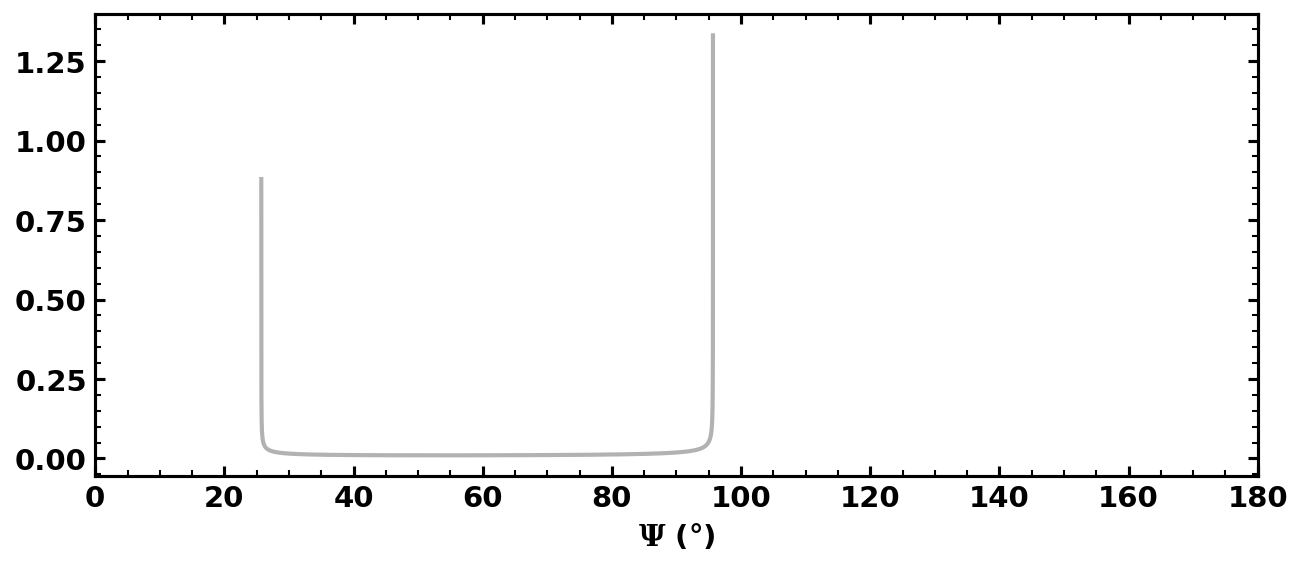

In [34]:
which_pop = 'PD'
test_df = df_PD.copy()

targ_names = test_df['Target'].values

for set_element_i in range(len(targ_names)):

    simbad_name = targ_names[set_element_i]

    target_str = targ_names[set_element_i].replace(' ', '')
    if '/' in targ_names[set_element_i]:
        target_str = target_str.replace('/', '-')
    if '(' in target_str:
        target_str = target_str.split('(')[0]

    if target_str == 'AS209':
    
        if which_pop == 'PD':
            Pdensity = pd.read_csv('/Users/lb8137/PROJECTS/PRIMORDIAL_OBLIQUITY/Backup/Tables/Probability_Distributions/High_Final/' + 'Prob_' + target_str + '.csv')
        else:
            if which_pop == 'DD':
                Pdensity = pd.read_csv(probability_distributions_dir + 'Prob_' + target_str + '.csv')
            else:
                Pdensity = pd.read_csv(probability_distributions_dir + 'Posteriors_' + target_str + '_' + which_pop + '.csv')
        i_values = Pdensity['i (deg)'].values

        P_i_disk = Pdensity['P(i Disk | d)'].values
        MAP_i_disk = Pdensity['i Disk MAP'].values[0]
        sig1_m_i_disk = Pdensity['i Disk -Unc1'].values[0]
        sig1_p_i_disk = Pdensity['i Disk +Unc1'].values[0]
        sig2_m_i_disk = Pdensity['i Disk -Unc2'].values[0]
        sig2_p_i_disk = Pdensity['i Disk +Unc2'].values[0]

        P_i_star = Pdensity['P(i Star | d)'].values
        MAP_i_star = Pdensity['i Star MAP'].values[0]
        sig1_m_i_star = Pdensity['i Star -Unc1'].values[0]
        sig1_p_i_star = Pdensity['i Star +Unc1'].values[0]
        sig2_m_i_star = Pdensity['i Star -Unc2'].values[0]
        sig2_p_i_star = Pdensity['i Star +Unc2'].values[0]

        P_Delta_i = Pdensity['P(Delta i | d)'].values
        MAP_Delta_i = Pdensity['Delta i MAP'].values[0]
        sig1_m_Delta_i = Pdensity['Delta i -Unc1'].values[0]
        sig1_p_Delta_i = Pdensity['Delta i +Unc1'].values[0]
        sig2_m_Delta_i = Pdensity['Delta i -Unc2'].values[0]
        sig2_p_Delta_i = Pdensity['Delta i +Unc2'].values[0]

        Psi_deg, Prob_Psi = Prob_Psi_Given_istar_iorbit(i_star_deg=MAP_i_star, i_orbit_deg=MAP_i_disk, dx=np.diff(i_values)[0], verbose=True)

print(MAP_i_star)
print(MAP_i_disk)
print(Prob_Psi)


fig = plt.figure(figsize=(10, 4), dpi=150)
ax = plt.subplot(111)
ax.minorticks_on()

ax.plot(Psi_deg, Prob_Psi, color='#000000', lw=2, alpha=0.30)
ax.set_xlabel(r'$\Psi$ ($\degree$)', fontsize=14)
ax.set_xlim(0, 180)
# ax.set_ylim(0, 120)
# ax.set_yticks([])
ax.tick_params(labelsize=14)
plt.show()

        